In [1]:
import numpy as np
import pandas as pd
from os.path import expanduser
from glob import glob
import time
import tputils as tpu
import socket

if ('gs553s' in socket.gethostname()) | ('GSLAL' in socket.gethostname()):
    basedir = expanduser('~/data/scipa_tvac/')
else:
    basedir = '/explore/nobackup/people/tperera/data/scipa_tvac/'

basedir = 'data/CFA/'
# spicific dataset to analyze

# test_type: 0 - high flux, 1 - high flux w/ repeats, 2 - special test

# band, side, test_type, visitstr = 2, 'B', 0, '0077101001'
band, side, test_type, visitstr = 6, 'B', 1, '0077101002'
# band, side, test_type, visitstr = 5, 'B', 2, '0077101003'
# band, side, test_type, visitstr = 6, 'B', 2, '0077101004'

# band, side, test_type, visitstr = 2, 'A', 0, '0077101005'
# band, side, test_type, visitstr = 6, 'A', 1, '0077101006'

testtag = 'HF' if test_type<2 else 'SP'

# if side=='B':
#     directory = basedir+f'B{band:d}{testtag}_CFA/'
# else:
#     directory = basedir+f'B{band:d}{testtag}_sideA_CFA/'

# print(directory)


# datlabel = f'Band{band:d}{testtag}_side{side}'

# savdir = directory+'savs/'
        
rcs_telem_fn = glob(basedir+f'*B{band:d}{testtag}.parquet')[0]
print(rcs_telem_fn)


data/CFA/25091813_CFA_B6HF.parquet


In [2]:
# read in rcs telemetry and define variables
# st = time.time()
cdf = pd.read_parquet(rcs_telem_fn)
# print(f'Telemetry file read time was {time.time()-st:.1f}')


times = np.array(cdf.index)
tfromstart = (times - times[0]) / np.timedelta64(1, 's')
code1 = np.array(cdf.loc[:, 'WFI_MCE_SRCS_BANK1_LED_I']) + \
    np.array(cdf.loc[:, 'WFI_MCE_SRCS_BANK1_LED_I_RANGE'], dtype='uint32')*(1<<16)
tfv1 = np.array(cdf.loc[:, 'WFI_MCE_SRCS_BANK1_LED_V'])
code2 = np.array(cdf.loc[:, 'WFI_MCE_SRCS_BANK2_LED_I']) + \
    np.array(cdf.loc[:, 'WFI_MCE_SRCS_BANK2_LED_I_RANGE'], dtype='uint32')*(1<<16)
tfv2 = np.array(cdf.loc[:, 'WFI_MCE_SRCS_BANK2_LED_V'])
tpd1 = np.array(cdf.loc[:, 'WFI_MCE_SRCS_PD1_V'])
tpd2 = np.array(cdf.loc[:, 'WFI_MCE_SRCS_PD2_V'])
tint1 = (np.array(cdf.loc[:, 'WFI_MCE_SRCS_PD1_INTOUTPUT_UPPER'], dtype='uint64')*(1<<32) + 
    np.array(cdf.loc[:, 'WFI_MCE_SRCS_PD1_INTOUTPUT_LOWER']))*5./2**24
tint2 = (np.array(cdf.loc[:, 'WFI_MCE_SRCS_PD2_INTOUTPUT_UPPER'], dtype='uint64')*(1<<32) + 
    np.array(cdf.loc[:, 'WFI_MCE_SRCS_PD2_INTOUTPUT_LOWER']))*5./2**24
tbrdT = np.array(cdf.loc[:, 'WFI_MCE_SRCS_BOARD_T'])
tsphT = np.array(cdf.loc[:, 'WFI_MCE_SRCS_SPHERE_T'])
if side=='B':
    band_to_LEDnum = {
        1: 1,
        2: 3,
        3: 2,
        4: 4,
        5: 6,
        6: 5
    }
else:
    band_to_LEDnum = {
        1: 6,
        2: 1,
        3: 2,
        4: 3,
        5: 4,
        6: 5
    }
    
on1 = np.array(cdf.loc[:, f'WFI_MCE_SRCS_BANK1SEL_LED{band_to_LEDnum[band]:d}'])
on2 = np.array(cdf.loc[:, f'WFI_MCE_SRCS_BANK2SEL_LED{band_to_LEDnum[band]:d}'])
ndat = len(times)
indarr = np.arange(ndat)
ilsettle = 20 if band<4 else 60

LEDcurr1 = on1*code1
LEDcurr2 = on2*code2
perinds = np.where( (np.diff(LEDcurr1)!=0) | (np.diff(LEDcurr2)!=0) )[0] + 1
print(perinds)

tmp = [0]
while len(perinds)>0:
    if perinds[0]<=(tmp[-1]+30):
        tmp[-1] = perinds[0]
    else:
        tmp.append(perinds[0])
    perinds = perinds[1:]
perinds = np.array(tmp)


[  479   510   830   843   874  1742  1773  1941  1943  2631  2662  4377
  4389  4420  5291  5322  5939  5942  6629  6660  7136  7167  7513  7516
  7529  7560  8318  8349  8603  8615  8646  8864  8866  9554  9585  9775
  9806  9964  9966  9978 10009 11292 11323 11522 11534 11565 11763 11766
 12491 12522 12985 12998 13029 14207 14238 15059 15760 15772 15803 16416
 16447 17005 17019 17050 17494 17496 18184 18215 18567 18598 18888 18890
 18902 18933 19754 19785 20078 20090 20121 20376 20378 21065 21096 21434
 21447 21500 21728 21759 22018 22781 22793 22903 23095 23126 23307 23319
 23372 23570 23573 24298 24362 24576 24588 24727 24908]


In [3]:
# identify precharge steps
startskip = 1
whpc = []
for i, (pi, npi) in enumerate( zip( perinds[:-1], perinds[1:]) ):
    if ( (LEDcurr1[pi+startskip]>LEDcurr1[npi+startskip]) & (LEDcurr1[npi+startskip]!=0) ) | \
       ( (LEDcurr2[pi+startskip]>LEDcurr2[npi+startskip]) & (LEDcurr2[npi+startskip]!=0) ):
       whpc.append(i) 
whpc = np.array(whpc)
mpc = np.zeros(len(perinds)).astype('int16')
if len(whpc)>0:
    mpc[whpc] = 1

if 0:
    peri = np.append(perinds, ndat-1)
    # show perinds and the states
    for i, (pe, pen) in enumerate(zip(peri[:-1], peri[1:])):
        print(f' {pen-pe:5d}: {LEDcurr1[pe+startskip]:6d}, {LEDcurr2[pe+startskip]:6d} {mpc[i]:d}')

mpc = mpc.astype('bool')
perinds = perinds[np.invert(mpc)]

if 1:
    peri = np.append(perinds, ndat-1)
    # show perinds and the states
    for i, (pe, pen) in enumerate(zip(peri[:-1], peri[1:])):
        print(f' {LEDcurr1[pe+startskip]:6d}, {LEDcurr2[pe+startskip]:6d}')



      0,      0
   6383,      0
      0,  12357
   6383,  12357
      0,      0
   6383,      0
      0,  12357
   6383,  12357
      0,      0
  20453,      0
  20453,  12357
      0,  28987
   6383,  28987
  20453,  28987
      0,      0
  64832,      0
  64832,  28987
      0,  65613
  20453,  65613
  64832,  65613
      0,      0
  20453,      0
  64832,      0
  64832,  28987
      0,  28987
      0,  65613
  20453,  65613
  64832,  65613
      0,      0
  66122,      0
  66122,  65613
      0,  67110
  64832,  67110
  66122,  67110
      0,      0
  66122,      0
  69282,      0
  69282,  67110
      0,  67110
      0,  73851
  66122,  73851
  69282,  73851
      0,      0
  69282,      0
      0,  73851
      0,      0


In [4]:
# load exposure times for this test
exptimefn = basedir+'exptimes.npz'
exptime_dict = dict(np.load(exptimefn))

# load seq info about test and figure out the kept exposures' numbers
df = pd.read_excel(f'{basedir}B{band:d}{testtag}_seq.xlsx')
nramps = np.array(df['nexp'])
norigramps = np.array(df['onexp'])
nsumramps = np.insert(np.cumsum(norigramps)[:-1], 0, 0)
orig_expnums = []
for nr, ns in zip(nramps, nsumramps):
    orig_expnums.extend(np.arange(ns, ns+nr))
orig_expnums = np.array(orig_expnums)

exptimes = exptime_dict[visitstr][orig_expnums]

rampnum = np.array([ir for nr in nramps for ir in range(nr)])
pernum = np.array([i for (i, nr) in enumerate(nramps) for ir in range(nr)])

# Side B B2HF: 2025-09-18T08:40 to 2025-09-18T12:40
# Side B B6HF: 2025-09-18T13:00 to 2025-09-18T20:10
# Side B B5SP: 2025-09-18T21:20 to 2025-09-19T04:30
# Side B B5SP: 2025-09-19T04:40 to 2025-09-19T12:00
# Side A B2HF: 2025-09-29T01:20 to 2025-09-29T05:10
# Side A B6HF: 2025-09-29T05:40 to 2025-09-29T13:00


In [5]:
rampnum

array([0, 1, 2, 0, 1, 2, 0, 1, 2, 3, 4, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1,
       2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 3, 4, 0, 1, 2, 0,
       1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0,
       1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 3,
       4, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2,
       3, 4, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 3, 4,
       0, 1, 2, 3, 4, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 4, 0, 1, 2, 3,
       4, 0, 1, 2, 0, 1, 2, 3, 0, 1, 2, 3, 4])

In [6]:
# First make period-by-period states based on currents.  
# Then make exposure-by-exposure states
ccode1 = LEDcurr1[perinds+startskip]
ccode2 = LEDcurr2[perinds+startskip]
nper = len(perinds)
code_pairs = np.array([[ccode1[pn], ccode2[pn]] for pn in range(nper)])

Asing = np.unique(code_pairs[:,0])
Bsing = np.unique(code_pairs[:,1])
Alevels = len(Asing)
Blevels = len(Bsing)

perstates = []
for cp in code_pairs:
    Aind = np.where(Asing==cp[0])[0][0]
    Bind = np.where(Bsing==cp[1])[0][0]
    perstates.append([Aind, Bind])
perstates = np.array(perstates)    

statebase = np.max([Alevels, Blevels])
perstatenum = np.array([s[0] + s[1]*statebase for s in perstates])

states = perstates[pernum]
statenum = perstatenum[pernum]

nexp = len(statenum)


In [7]:
# gather/process telemetry data

def ret_tr_stats(tr, settle=0, std=False):
    trtr = tr[settle:]
    trtr = trtr[np.invert(np.isnan(trtr))]
    ms, vs = tpu.robust_meanvar(trtr)
    mse = np.sqrt( vs[0] / len(trtr) )

    retlist = [ms[0], mse]

    if std:
        retlist.append(np.sqrt(vs[0]))
    
    return tuple(retlist)

def int_to_val(integral, v):
    intdiffs = np.diff(integral)
    ns = np.round( intdiffs / (.5*(v[:-1]+v[1:])) ).astype('int16')
    m = (ns>150)&(ns<155)
    retvals = np.zeros(len(m))
    retvals[m] = intdiffs[m]/ns[m]
    return retvals, m

pdlabels = [f'{side} InGaAs', f'{side} MCT']
npd = len(pdlabels)

# period trace holders
pdtraces = [0]*nper
fv1traces = [0]*nper
fv2traces = [0]*nper
brdTtraces = [0]*nper
sphTtraces = [0]*nper
timetraces = [0]*nper
perstinds = np.zeros(nper, dtype='int16')
pereninds = np.zeros(nper, dtype='int16')

# exposure-by-exposure mean holders
PDvolts = np.zeros((npd, nexp))
PDverrs = np.zeros((npd, nexp))
PDvstd = np.zeros((npd, nexp))
fv1m = np.zeros(nexp)
fv2m = np.zeros(nexp)
brdTm = np.zeros(nexp)
sphTm = np.zeros(nexp)
midtime = np.zeros(nexp)
expdur = np.zeros(nexp)

useint = True

for ipn in range(nper):
    whper = np.where(pernum==ipn)[0]
    perstinds[ipn] = whper[0]
    pereninds[ipn] = whper[-1]
    persttime = exptimes[perstinds[ipn], 0]
    perentime = exptimes[pereninds[ipn], 1]
    mper = (times>persttime) & (times<perentime)
    if np.sum(mper)<5: continue
    if useint:
        rawpd1 = tpd1[mper]
        rawpd2 = tpd2[mper]
        pd1, ma1 = int_to_val(tint1[mper], rawpd1)
        pd2, ma2 = int_to_val(tint2[mper], rawpd2)
        pd1[np.invert(ma1)] = rawpd1[1:][np.invert(ma1)]
        pd2[np.invert(ma2)] = rawpd2[1:][np.invert(ma2)]
    else:
        pd1 = tpd1[mper][1:]
        pd2 = tpd2[mper][1:]
    pdtraces[ipn] = [pd1, pd2] 
    fv1traces[ipn] = tfv1[mper][1:]
    fv2traces[ipn] = tfv2[mper][1:]
    brdTtraces[ipn] = tbrdT[mper][1:]
    sphTtraces[ipn] = tsphT[mper][1:]
    timetraces[ipn] = tfromstart[mper][1:]

    for iexp in np.arange(perstinds[ipn], pereninds[ipn]+1):
        midtime[iexp] = np.mean(
            (exptimes[iexp] - times[0]) / np.timedelta64(1, 's')
            )
        expdur[iexp] = np.diff(exptimes[iexp])[0] / np.timedelta64(1, 's')
        mexp = (times>exptimes[iexp, 0]) & (times<exptimes[iexp, 1])
        if np.sum(mexp)<2: continue
        if useint:
            rawpd1 = tpd1[mexp]
            rawpd2 = tpd2[mexp]
            pd1, ma1 = int_to_val(tint1[mexp], rawpd1)
            pd2, ma2 = int_to_val(tint2[mexp], rawpd2)
            
            pd1[np.invert(ma1)] = rawpd1[1:][np.invert(ma1)]
            pd2[np.invert(ma2)] = rawpd2[1:][np.invert(ma2)]
        else:
            pd1 = tpd1[mexp][1:]
            pd2 = tpd2[mexp][1:]
        PDvolts[0, iexp], PDverrs[0, iexp], PDvstd[0, iexp] \
            = ret_tr_stats(pd1, std=True)
        PDvolts[1, iexp], PDverrs[1, iexp], PDvstd[1, iexp] \
            = ret_tr_stats(pd2, std=True)
        fv1m[iexp], _ = ret_tr_stats(tfv1[mexp][1:])
        fv2m[iexp], _ = ret_tr_stats(tfv2[mexp][1:])
        brdTm[iexp], _ = ret_tr_stats(tbrdT[mexp][1:])
        sphTm[iexp], _ = ret_tr_stats(tsphT[mexp][1:])



In [17]:
pernum

array([ 0,  0,  0,  1,  1,  1,  2,  2,  2,  2,  2,  3,  3,  3,  4,  4,  4,
        5,  5,  5,  6,  6,  6,  7,  7,  7,  8,  8,  8,  9,  9,  9, 10, 10,
       10, 11, 11, 11, 11, 11, 12, 12, 12, 13, 13, 13, 14, 14, 14, 15, 15,
       15, 16, 16, 16, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 19, 19, 19,
       19, 19, 20, 20, 20, 20, 20, 21, 21, 21, 22, 22, 22, 23, 23, 23, 24,
       24, 24, 24, 24, 25, 25, 25, 26, 26, 26, 27, 27, 27, 28, 28, 28, 29,
       29, 29, 30, 30, 30, 31, 31, 31, 31, 31, 32, 32, 32, 33, 33, 33, 34,
       34, 34, 35, 35, 35, 36, 36, 36, 37, 37, 37, 37, 37, 38, 38, 38, 38,
       38, 39, 39, 39, 39, 40, 40, 40, 40, 41, 41, 41, 41, 41, 42, 42, 42,
       42, 42, 43, 43, 43, 44, 44, 44, 44, 45, 45, 45, 45, 45])

Text(0.5, 0.98, 'Dark Subtracted PD Error vs. Signal')

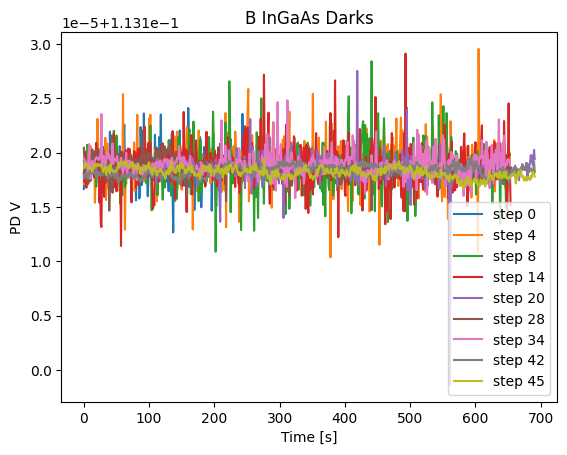

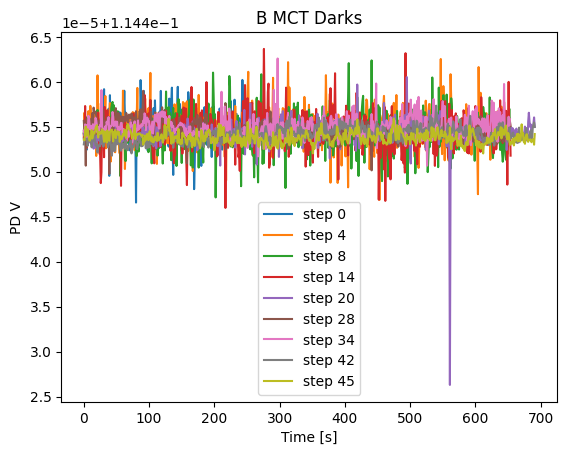

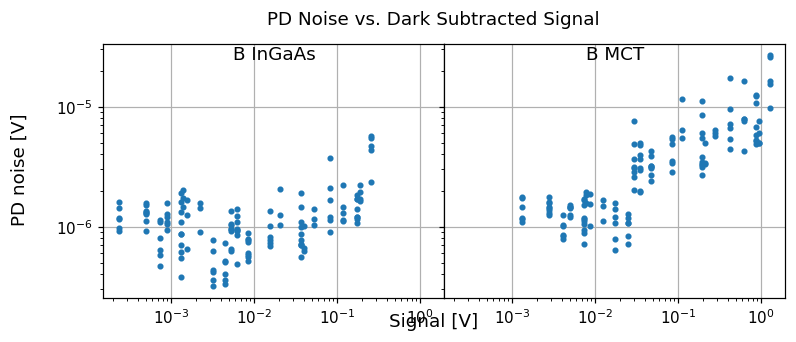

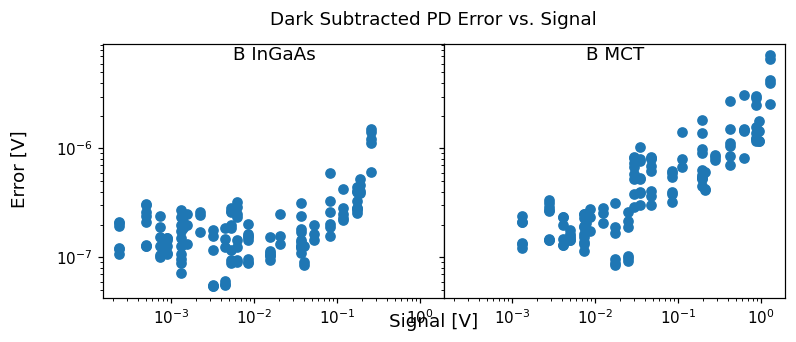

In [8]:
# dark subtraction and treatment of illuminated periods

from tqdm import tqdm
import copy
import lmFLUXsuite as lmf
import matplotlib.pyplot as plt
savpdtraces = copy.deepcopy(pdtraces)

stepcurr1 = np.array([lmf.hex_to_current(side, 1, cc) for cc in ccode1])
stepcurr2 = np.array([lmf.hex_to_current(side, 2, cc) for cc in ccode2])
stepcurrtot = stepcurr1 + stepcurr2

# apply PF offset correction
# offset_slope = 1.52e-3
offset_slope = 1.35e-3
apply_corr = True
if apply_corr:
    PDvolts += stepcurrtot[pernum]*offset_slope
    for iper in range(nper):
        for ipd in range(npd):
            pdtraces[iper][ipd] += stepcurrtot[iper]*offset_slope

# plot dark traces
whdark = np.where(perstatenum==0)[0]
for ipd in range(npd):
    plt.figure(dpi=100)
    for wh in whdark:
        plt.plot(pdtraces[wh][ipd][5:], label=f'step {wh}')
    plt.legend()
    plt.xlabel('Time [s]')
    plt.ylabel('PD V')
    plt.title(pdlabels[ipd]+' Darks')
    

# dark subtract first at the exposure level
whlight = np.where(statenum!=0)[0]
nilexp = len(whlight)
dk_interp = np.zeros((npd, nilexp))
PDsigs = np.zeros((npd, nilexp))
PDerrs = np.zeros((npd, nilexp))
PDnoise = np.zeros((npd, nilexp))
whdark = np.where( (statenum==0) & (PDvolts[0]>0.) & (PDvolts[1]>0.) )[0]
# using only successful PDvolts for intepolation
for ipd in range(npd):
    dk_interp[ipd] = np.interp(midtime[whlight], midtime[whdark], PDvolts[ipd, whdark])
    PDsigs[ipd] = PDvolts[ipd, whlight] - dk_interp[ipd]
    dkvar_interp = np.interp(midtime[whlight], midtime[whdark], PDverrs[ipd, whdark]**2)
    PDerrs[ipd] = np.sqrt(PDverrs[ipd, whlight]**2 + dkvar_interp)
    PDnoise[ipd] = PDvstd[ipd, whlight]
orig_PDerrs = PDerrs.copy()

# dark-subtracted PD signals and erros AND just the illuminated means of other variables
ilfv1m = fv1m[whlight]
ilfv2m = fv2m[whlight]
ilbrdTm = brdTm[whlight]
ilsphTm = sphTm[whlight]
ilmidtime = midtime[whlight]
ilstates = states[whlight]

per_dk_interp = []
for ipn in range(nper):
    expinds = np.arange(perstinds[ipn], pereninds[ipn]+1)
    lightexpinds = []
    for ei in expinds:
        if ei not in whlight:
            break
        lightexpinds.append(np.where(whlight==ei)[0][0])
    if len(lightexpinds)>0:
        lightexpinds = np.array(lightexpinds)
        per_dk_interp.append(np.mean(dk_interp[:, lightexpinds], axis=-1))
per_dk_interp = np.array(per_dk_interp)

# apply dark subtraction to illuminated PD traces at the period level
whlight = np.where(perstatenum!=0)[0]
tmptraces = [pdtraces[wh] for wh in whlight]
dspdtraces = []

for iilper, trs in enumerate(tmptraces):
    for ipd in range(npd):
        trs[ipd] -= per_dk_interp[iilper, ipd]
    dspdtraces.append(trs)

ilfv1traces = [fv1traces[wh] for wh in whlight]
ilfv2traces = [fv2traces[wh] for wh in whlight]
ilbrdTtraces = [brdTtraces[wh] for wh in whlight]
ilsphTtraces = [sphTtraces[wh] for wh in whlight]
iltimetraces = [timetraces[wh] for wh in whlight]
ilpers = np.arange(nper)[whlight]

# diagnostic plots

# Dark subtracted noise
fig, ax = plt.subplots(npd//2, 2, figsize=(2*4., (npd//2)*3.), sharex=True, sharey=True, dpi=110)
fig.subplots_adjust(wspace=0., hspace=0.)
if ax.ndim==1:
    ax = ax.reshape(1, -1)
for ipd in range(npd):
    irow = ipd // 2
    icol = ipd % 2
    ax[irow, icol].loglog(PDsigs[ipd], PDnoise[ipd], '.')
    ax[irow, icol].set_title(pdlabels[ipd], y=0.9)
    ax[irow, icol].grid()
fig.supxlabel('Signal [V]')
fig.supylabel(f'PD noise [V]')
fig.suptitle('PD Noise vs. Dark Subtracted Signal')

# Dark subtracted in-principle error bars vs signal (based on short term noise) 
fig, ax = plt.subplots(npd//2, 2, figsize=(2*4., (npd//2)*3.), sharex=True, sharey=True, dpi=110)
fig.subplots_adjust(wspace=0., hspace=0.)
if ax.ndim==1:
    ax = ax.reshape(1, -1)
for ipd in range(npd):
    irow = ipd // 2
    icol = ipd % 2
    ax[irow, icol].loglog(PDsigs[ipd], PDerrs[ipd], 'o')
    ax[irow, icol].set_title(pdlabels[ipd], y=0.9)
fig.supxlabel('Signal [V]')
fig.supylabel('Error [V]')
fig.suptitle('Dark Subtracted PD Error vs. Signal')

# # Trend dark level and Board temeprature with time
# plt.figure(dpi=100)
# plt.errorbar(steptime[whdark], PDvolts[1, whdark], yerr=PDverrs[1, whdark], marker='o')
# plt.xlabel('Time [s]')
# plt.ylabel(pdlabels[1]+' Dark Signal [V]')
# plt.title('Time Trends')
# ax2 = plt.gca().twinx()
# ax2.plot(steptime[whdark], brdTm[whdark], 'x-', color='orange')
# ax2.tick_params(axis='y', labelcolor='orange')
# ax2.set_ylabel('Board T [C]', color='orange')


/var/folders/0w/vy9t9vf95gbf411s1q3ph0bm0000gp/T/ipykernel_74094/3751762896.py:63: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(plotrows, 2, figsize=(2*4., 1.25*plotrows+1.25), dpi=110,


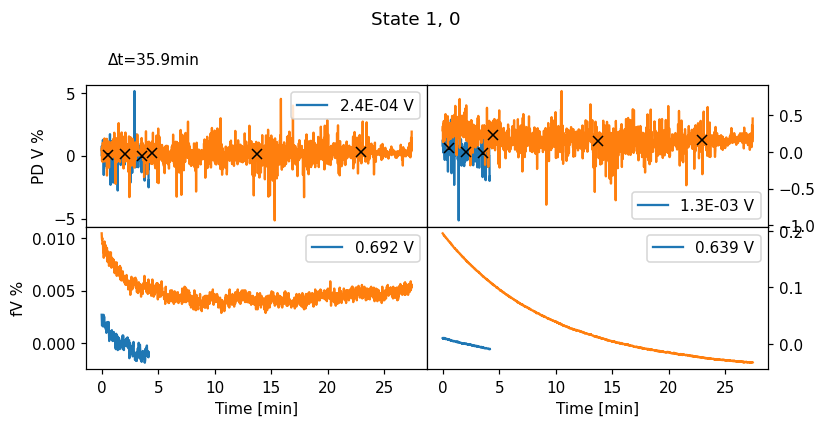

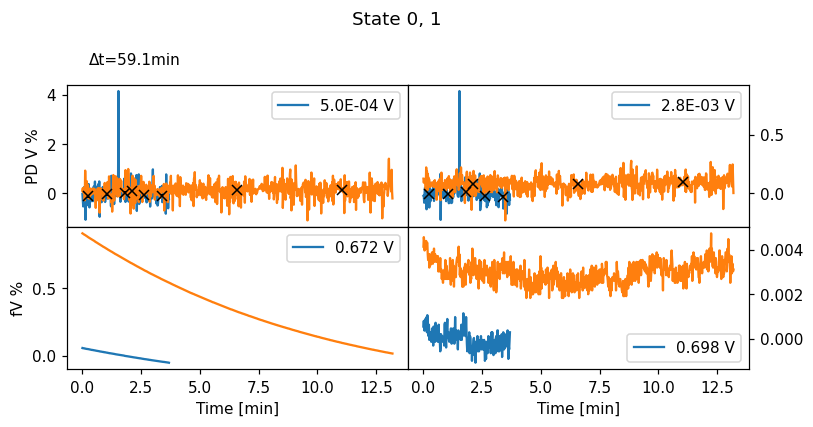

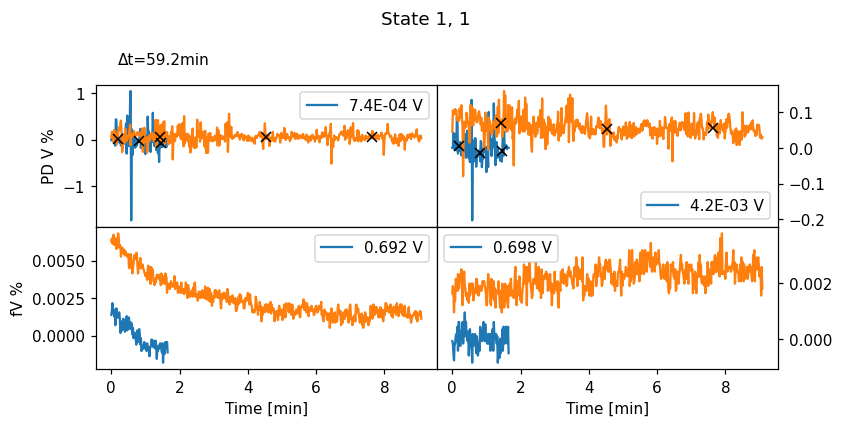

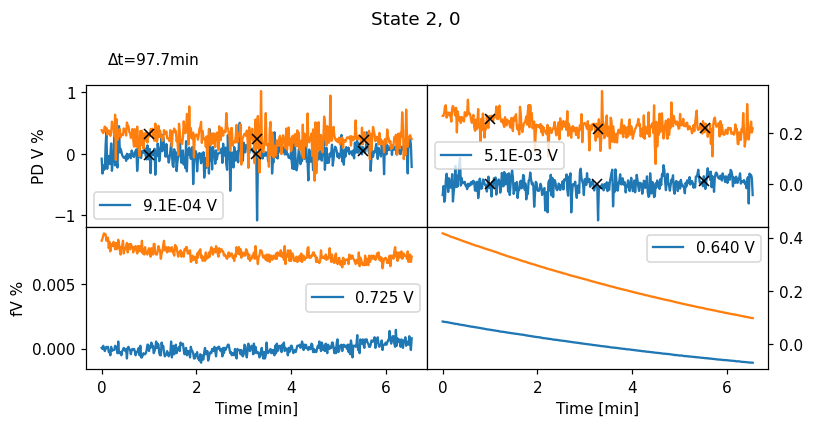

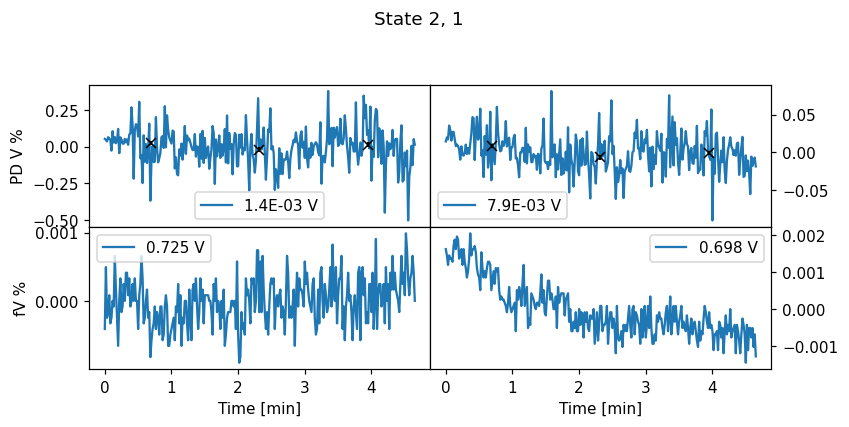

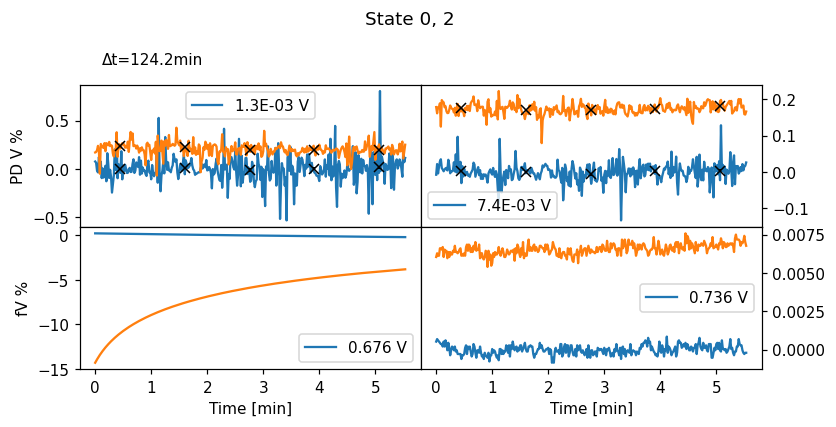

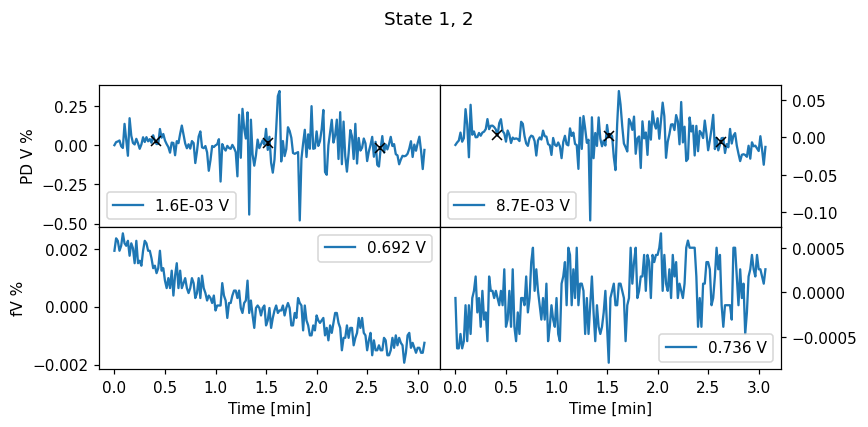

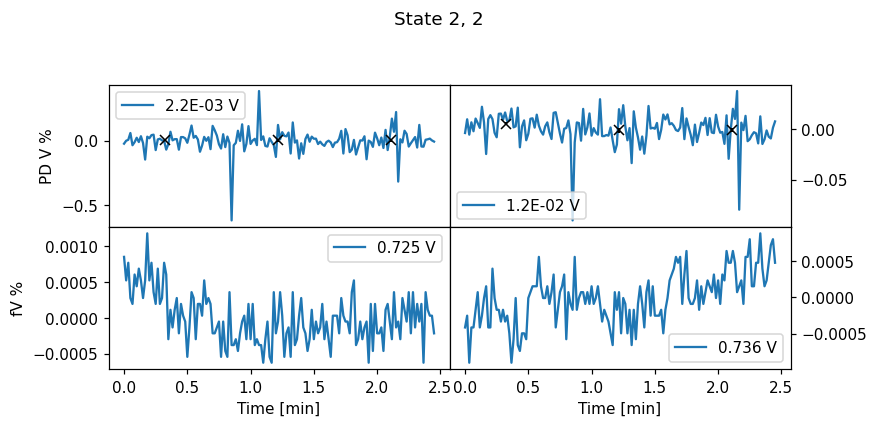

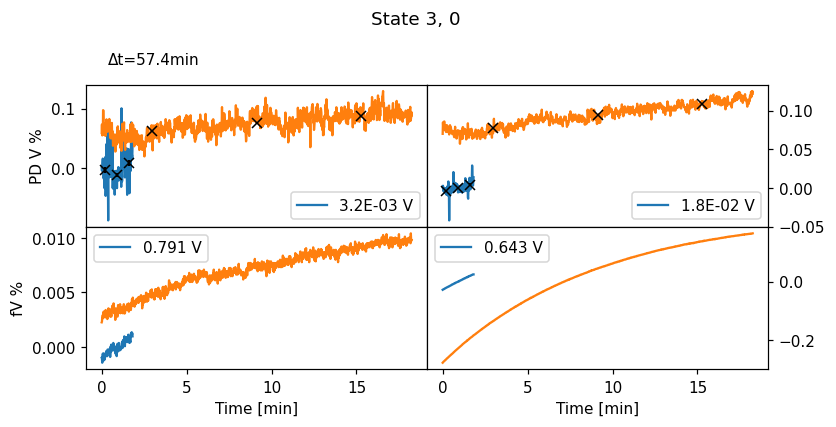

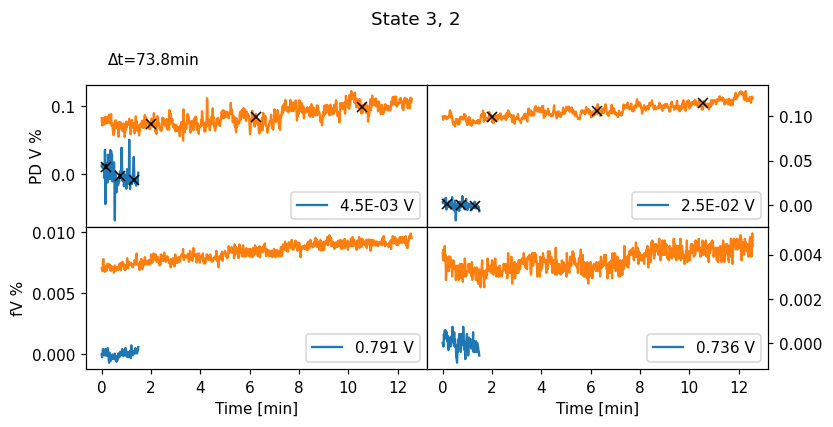

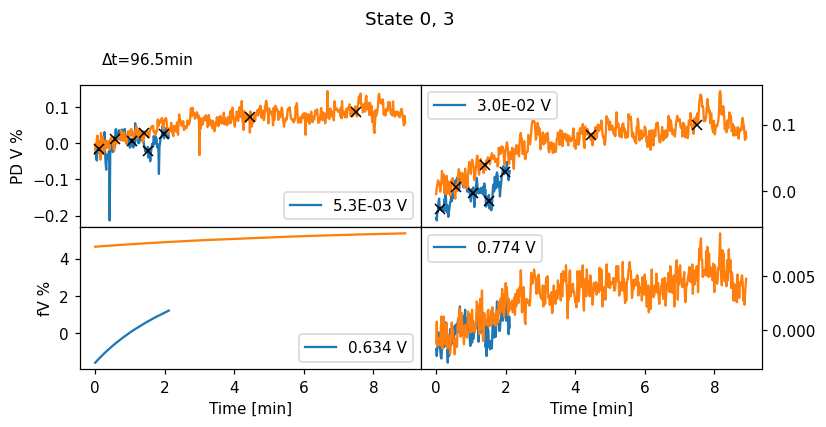

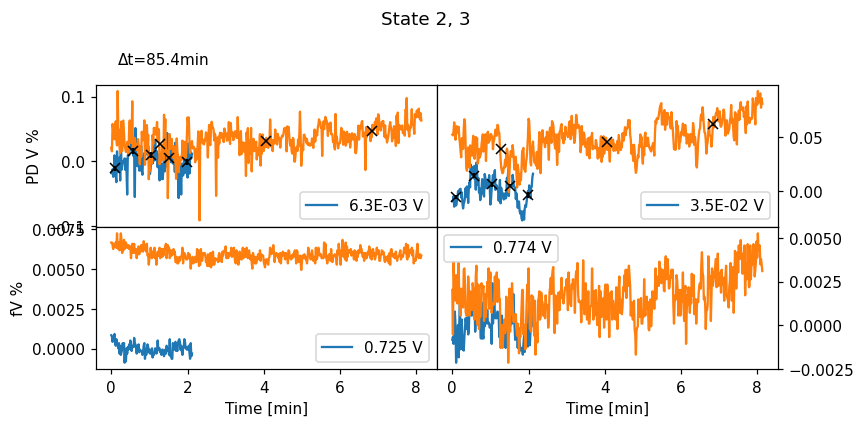

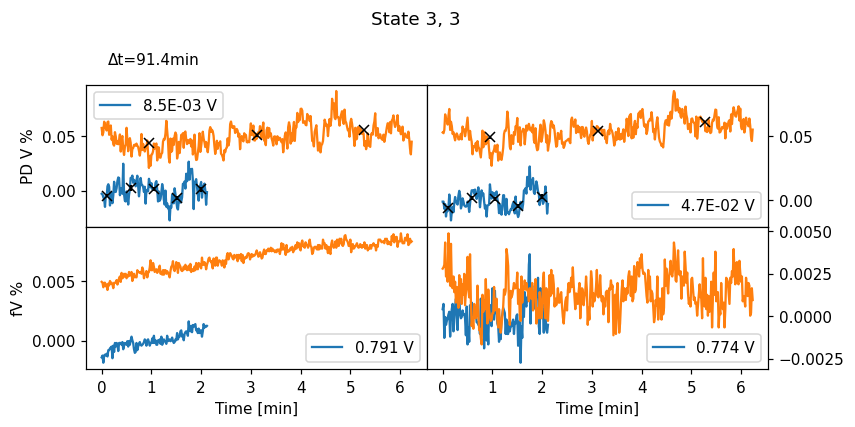

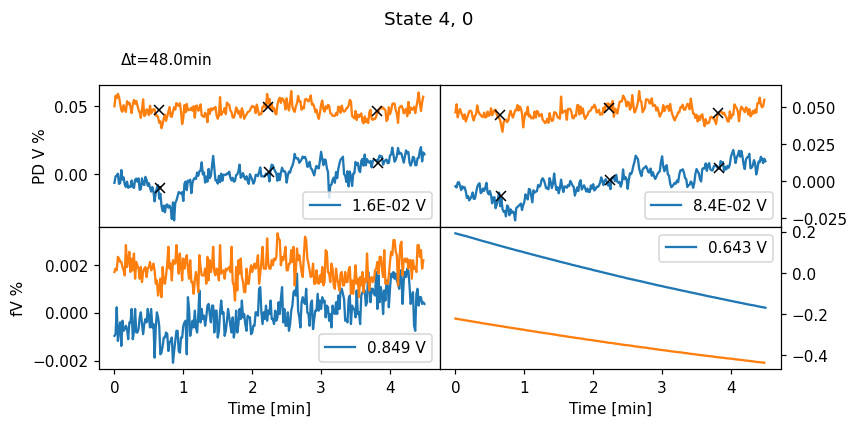

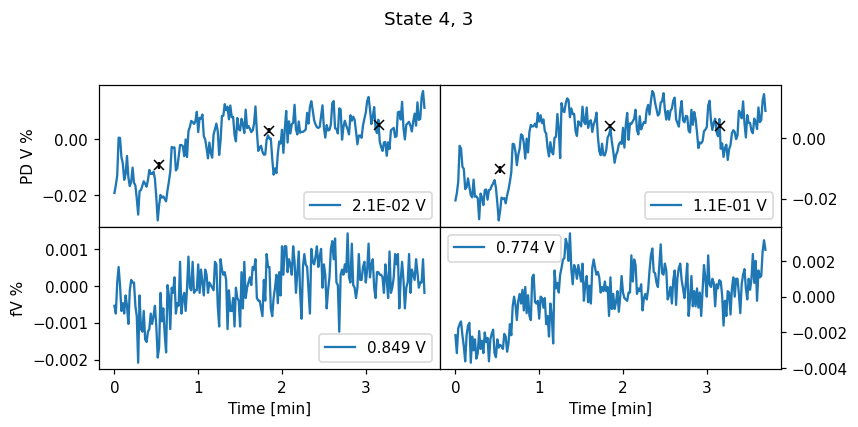

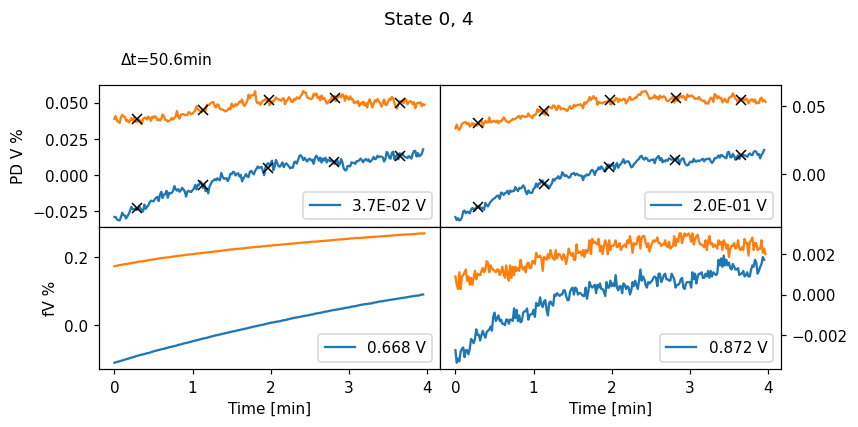

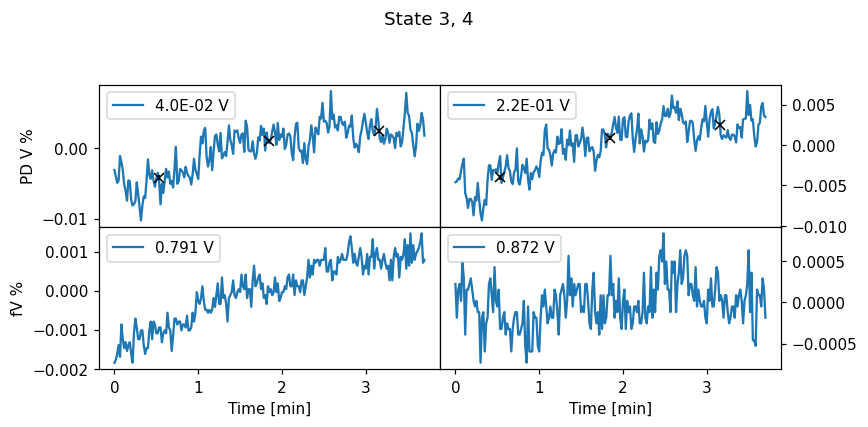

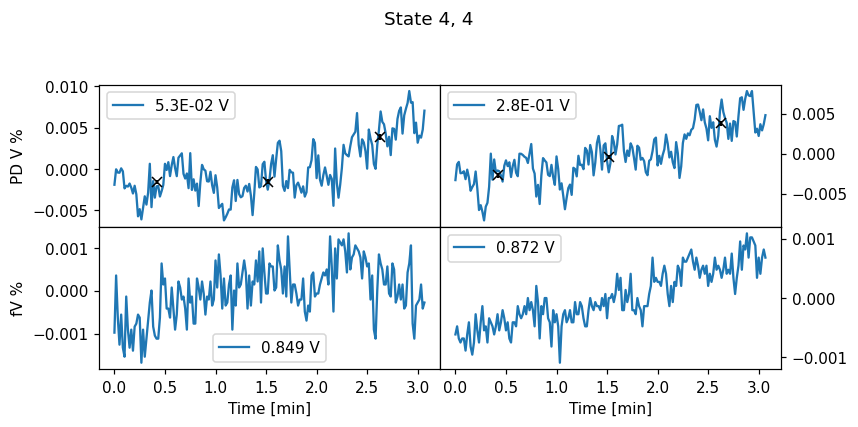

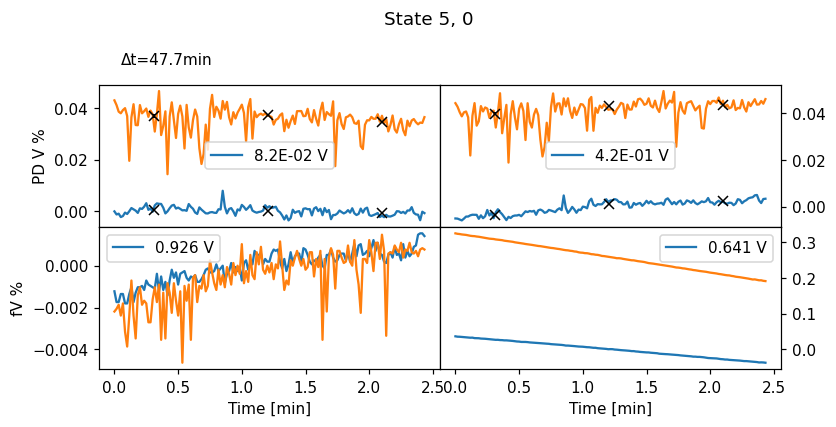

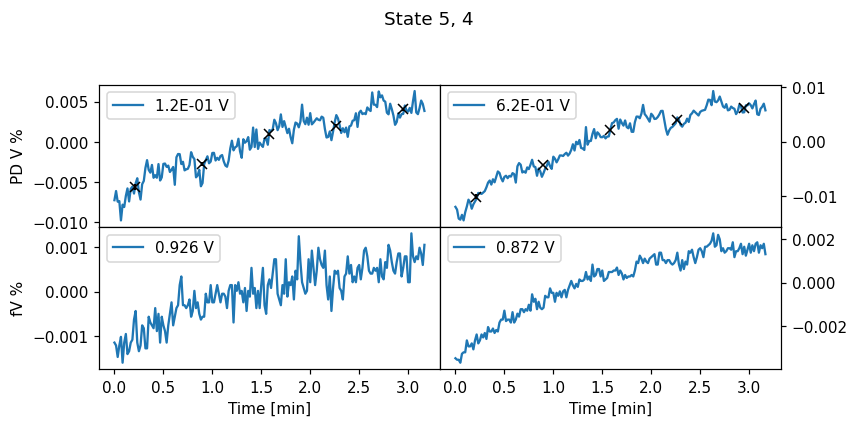

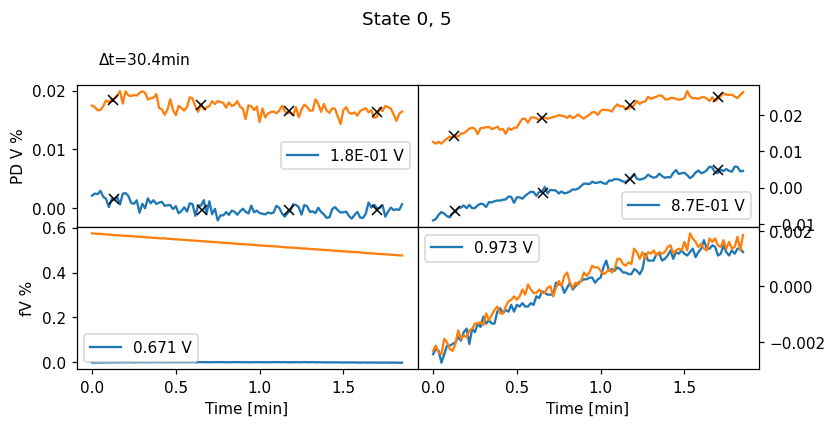

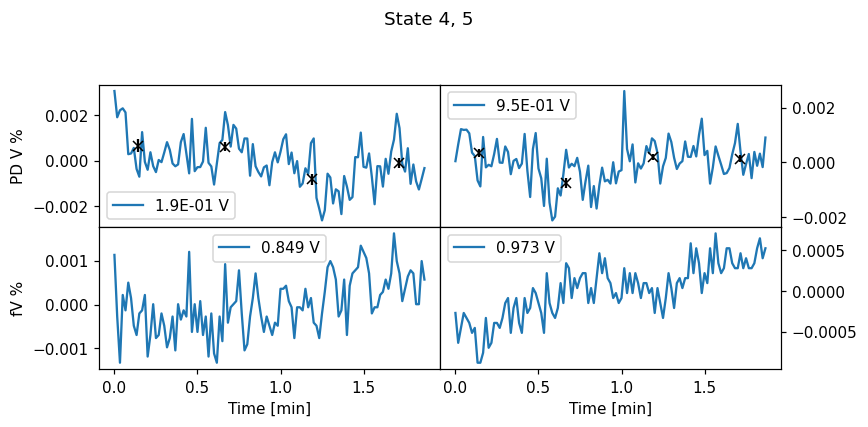

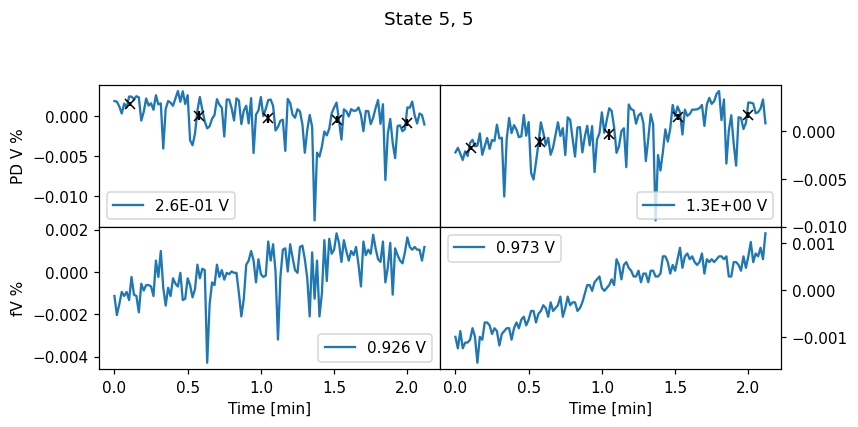

In [9]:
# percentage plot function

def percplot(axx, x, y, xl=None, yl=None, legformat='.2f',
             legunit=None, plsym=None):
    if not isinstance(x[0], (list, np.ndarray)):
        x = [x]
        y = [y]
        

    percdiffs = []
    for i in range(len(x)):
        if i==0:
            midval = np.mean(y[i])
            legstr = eval('f\'{midval:'+legformat+'}\'')
            if legunit is not None:
                legstr += f' {legunit}'
        else:
            legstr = ''
        percy = 100.*(np.array(y[i])/midval - 1.)
        if plsym is None:
            axx.plot(x[i], percy, label=legstr)
        else:
            axx.plot(x[i], percy, plsym, label=legstr)
        axx.legend()

        percdiffs.append(percy)

    if xl is not None:
        axx.set_xlabel(xl)
    if yl is not None:
        axx.set_ylabel(yl)

    return midval, percdiffs
        

plot_fvs = 1
plot_othTs = 0
plotrows = npd//2 + plot_fvs + plot_othTs
plskip = 15

b1pdperc = [0]*(Alevels-1)
b2pdperc = [0]*(Blevels-1)
b1fvperc = [0]*(Alevels-1)
b2fvperc = [0]*(Blevels-1)
b1fvdiff = [0]*(Alevels-1)
b2fvdiff = [0]*(Blevels-1)

covered_states = []
for iilper, ipn in enumerate(ilpers):
    istn = perstatenum[ipn]
    if istn in covered_states:
        continue
    else:
        covered_states.append(istn)
    ist = perstates[ipn]

    pns = np.where(perstatenum==istn)[0]
    ilpns = np.where(perstatenum[ilpers]==istn)[0]

    tstarts = [iltimetraces[ilp][0]/60. for ilp in ilpns]
    tstring = '' if len(tstarts)==1 else f'Δt={tstarts[1]-tstarts[0]:.1f}min'
    
    fig, ax = plt.subplots(plotrows, 2, figsize=(2*4., 1.25*plotrows+1.25), dpi=110,
                           sharex=True)
    fig.subplots_adjust(hspace=0, wspace=0., top=0.8)
    if ax.ndim==1:
        ax = ax.reshape(1, -1)
    xarrs = [iltimetraces[ilp]/60.-tstarts[ii] for ii, ilp in enumerate(ilpns)]
    xpts = [midtime[perstinds[pn]: pereninds[pn]+1]/60.-tstarts[ii] for ii, pn in enumerate(pns)]
    midpdv = [0]*2
    pdperc = [0]*2
    for ipd in range(npd):
        yarrs = [dspdtraces[ilp][ipd] for ilp in ilpns]
        irow = ipd // 2
        icol = ipd % 2
        if icol==0:
            ylab = 'PD V %'
        else:
            ylab = None
        if (irow+1)==plotrows:
            xlab = 'Time [min]'
        else:
            xlab = None
        midpdv[ipd], pdperc[ipd] = percplot(ax[irow, icol], xarrs, yarrs, xl=xlab, yl=ylab, legformat='.1E', legunit='V')
        for ii, pn in enumerate(pns):
            whilper = np.where(pernum[statenum!=0]==pn)[0]
            ilperstinds = whilper[0]
            ilpereninds = whilper[-1]
            ypts = 100.*(PDsigs[ipd, ilperstinds: ilpereninds+1]/midpdv[ipd] - 1.)
            yerrs = 100.*(orig_PDerrs[ipd, ilperstinds: ilpereninds+1])/midpdv[ipd]
            ax[irow, icol].errorbar(xpts[ii], ypts, yerr=yerrs,
                                    ls='none', marker='x', color='k')
            if icol==1:
                ax[irow, icol].yaxis.tick_right()
    fig.text(.15, .85, tstring)
    fig.suptitle(f'State {ist[0]}, {ist[1]}')

    if plot_fvs:
        irow += 1
        icol = 0
        yarrs = [ilfv1traces[ilp] for ilp in ilpns]
        ylab = 'fV %'
        if (irow+1)==plotrows:
            xlab = 'Time [min]'
        else:
            xlab = None
        midv1, fv1perc = percplot(ax[irow, icol], xarrs, yarrs, xl=xlab, yl=ylab, legformat='.3F', legunit='V')

        icol = 1
        yarrs = [ilfv2traces[ilp] for ilp in ilpns]
        ylab = None
        if (irow+1)==plotrows:
            xlab = 'Time [min]'
        else:
            xlab = None
        midv2, fv2perc = percplot(ax[irow, icol], xarrs, yarrs, xl=xlab, yl=ylab, legformat='.3F', legunit='V')
        ax[irow, icol].yaxis.tick_right()


    # gather PD and FV perc for single LED states
    
    if (ist[0]>0) & (ist[1]==0): # LED 1-only states
        b1pdperc[ist[0]-1] = pdperc
        b1fvperc[ist[0]-1] = fv1perc
        b1fvdiff[ist[0]-1] = [midv1*(fv/100.) for fv in fv1perc]
        
    if (ist[0]==0) & (ist[1]>0): # LED 2-only states
        b2pdperc[ist[1]-1] = pdperc
        b2fvperc[ist[1]-1] = fv2perc
        b2fvdiff[ist[1]-1] = [midv2*(fv/100.) for fv in fv2perc]
    

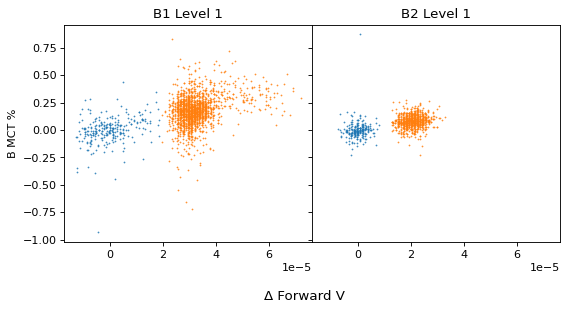

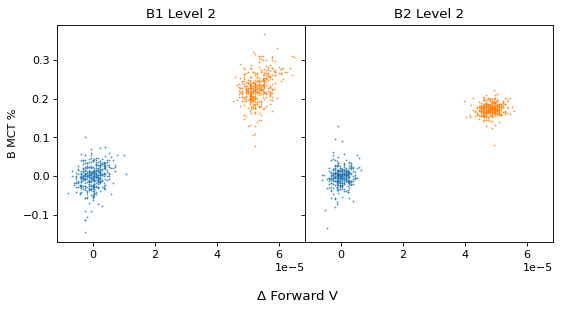

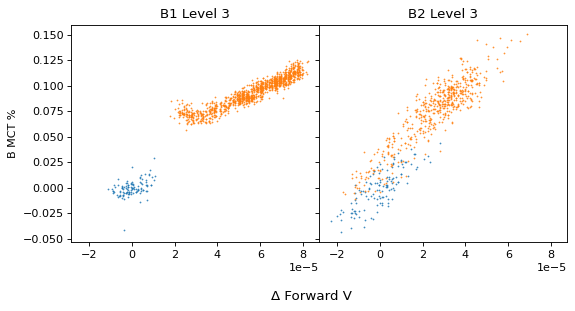

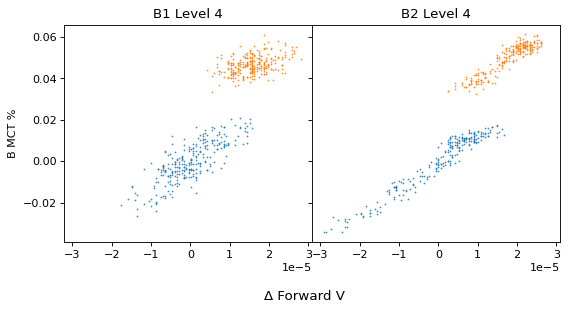

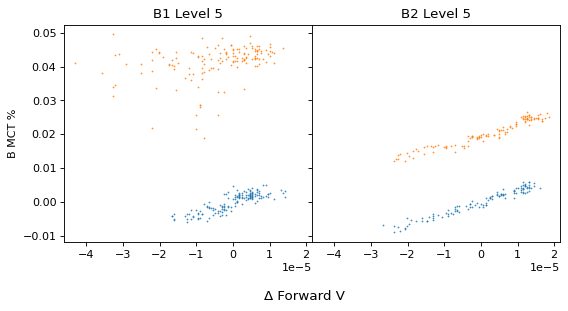

In [10]:
# plot forward-V to light level correlations

ipd = 1
levels = np.max([Alevels, Blevels])

for ilev in range(levels-1):
    fig, ax = plt.subplots(1, 2, figsize=(2*4., 4.), dpi=80,
                           sharex=True, sharey=True)
    fig.subplots_adjust(hspace=0, wspace=0., bottom=0.2)
    # for fvp, pdp in zip(b1fvperc[ilev], b1pdperc[ilev][ipd]):
    for fvp, pdp in zip(b1fvdiff[ilev], b1pdperc[ilev][ipd]):
        ax[0].plot(fvp, pdp, '.', markersize=1.)
    ax[0].set_title(f'B1 Level {ilev+1}')
    ax[0].set_ylabel(pdlabels[ipd]+' %')
    # for fvp, pdp in zip(b2fvperc[ilev], b2pdperc[ilev][ipd]):
    for fvp, pdp in zip(b2fvdiff[ilev], b2pdperc[ilev][ipd]):
        ax[1].plot(fvp, pdp, '.', markersize=1.)
    ax[1].set_title(f'B2 Level {ilev+1}')
    # fig.supxlabel('Forward V %')
    fig.supxlabel('Δ Forward V')
    

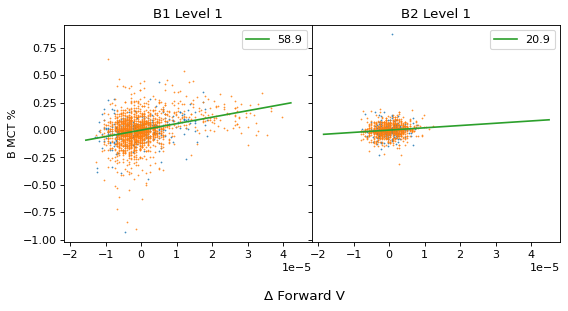

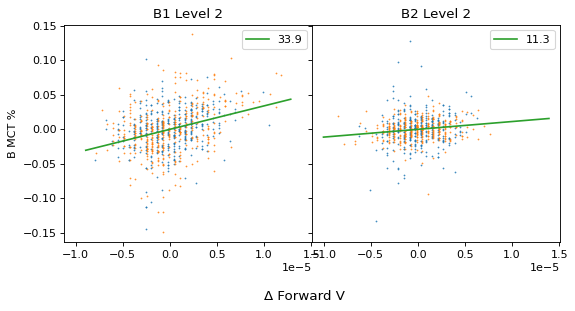

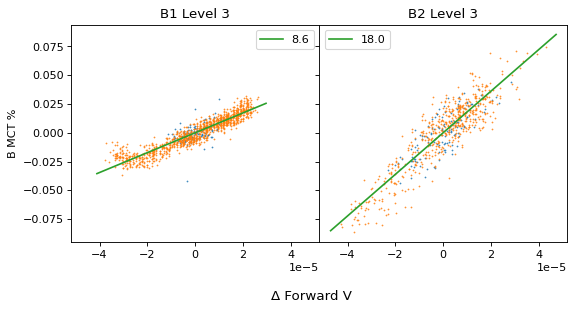

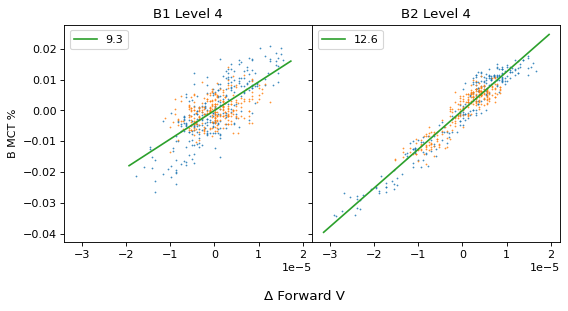

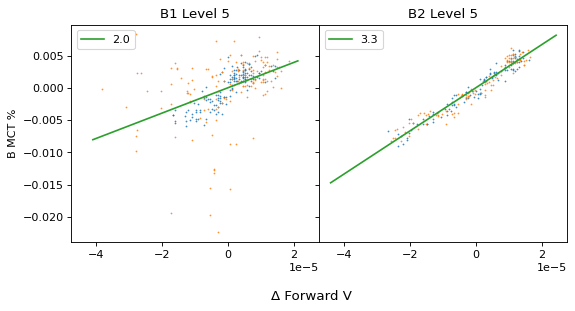

In [11]:
# find forward-V to light level correlations within single-LED on periods

ipd = 1
levels = np.max([Alevels, Blevels])

pdfv1slope = np.zeros(levels)
pdfv2slope = np.zeros(levels)

for ilev in range(levels-1):
    fig, ax = plt.subplots(1, 2, figsize=(2*4., 4.), dpi=80,
                           sharex=True, sharey=True)
    fig.subplots_adjust(hspace=0, wspace=0., bottom=0.2)

    centfvp = []
    centpdp = []
    # for fvp, pdp in zip(b1fvperc[ilev], b1pdperc[ilev][ipd]):
    for fvp, pdp in zip(b1fvdiff[ilev], b1pdperc[ilev][ipd]):
        fvp -= np.mean(fvp)
        pdp -= np.mean(pdp)
        ax[0].plot(fvp, pdp, '.', markersize=1.)
        centfvp.extend(fvp)
        centpdp.extend(pdp)
    centfvp = np.array(centfvp)
    centpdp = np.array(centpdp)
    pdfv1slope[ilev] = np.sum(centfvp*centpdp) / np.sum(centfvp**2) / 100.
    xx = np.linspace(*ax[0].get_xlim(), 100)
    ax[0].plot(xx, 100.*pdfv1slope[ilev]*xx, label=f'{pdfv1slope[ilev]:.1f}')
    ax[0].legend()
    ax[0].set_title(f'B1 Level {ilev+1}')
    ax[0].set_ylabel(pdlabels[ipd]+' %')
    
    centfvp = []
    centpdp = []
    # for fvp, pdp in zip(b2fvperc[ilev], b2pdperc[ilev][ipd]):
    for fvp, pdp in zip(b2fvdiff[ilev], b2pdperc[ilev][ipd]):
        fvp -= np.mean(fvp)
        pdp -= np.mean(pdp)
        ax[1].plot(fvp, pdp, '.', markersize=1.)
        centfvp.extend(fvp)
        centpdp.extend(pdp)
    centfvp = np.array(centfvp)
    centpdp = np.array(centpdp)
    pdfv2slope[ilev] = np.sum(centfvp*centpdp) / np.sum(centfvp**2) / 100.
    xx = np.linspace(*ax[1].get_xlim(), 100)
    ax[1].plot(xx, 100.*pdfv2slope[ilev]*xx, label=f'{pdfv2slope[ilev]:.1f}')
    ax[1].legend()
    ax[1].set_title(f'B2 Level {ilev+1}')
    # fig.supxlabel('Forward V %')
    fig.supxlabel('Δ Forward V')
    

In [12]:
pickexp = 1
fvfaf = np.zeros((len(ilstates), 2))

# find mean forward Vs per Alevel and Blevel
meanAfvs = np.zeros(Alevels-1)
meanBfvs = np.zeros(Blevels-1)
for lev in range(1, Alevels):
    mlev = states[:, 0]==lev
    meanAfvs[lev-1] = np.sum(fv1m[mlev]/PDverrs[ipd, mlev]**2) / np.sum(1./PDverrs[ipd, mlev]**2)
for lev in range(1, Blevels):
    mlev = states[:, 1]==lev
    meanBfvs[lev-1] = np.sum(fv2m[mlev]/PDverrs[ipd, mlev]**2) / np.sum(1./PDverrs[ipd, mlev]**2)

for pn in ilpers:
    whilper = np.where(pernum[statenum!=0]==pn)[0]
    ilstinds = np.arange(whilper[0], whilper[-1]+1)
    ist = ilstates[ilstinds[0]]
    midind = ilstinds[pickexp]
    if ist[0]>0: 
        # delfv1 = ilfv1m[ilstinds] - ilfv1m[midind]
        delfv1 = ilfv1m[ilstinds] - meanAfvs[ist[0]-1]
        fvfaf[ilstinds, 0] = delfv1*pdfv1slope[perstates[pn, 0]-1]
    if ist[1]>0:
        # delfv2 = ilfv2m[ilstinds] - ilfv2m[midind]
        delfv2 = ilfv2m[ilstinds] - meanBfvs[ist[1]-1]
        fvfaf[ilstinds, 1] = delfv2*pdfv2slope[perstates[pn, 1]-1]


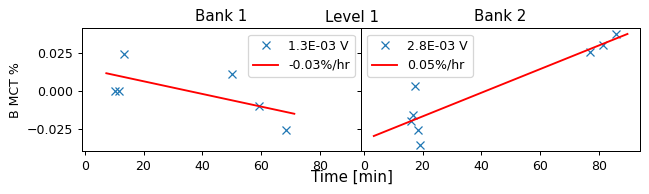

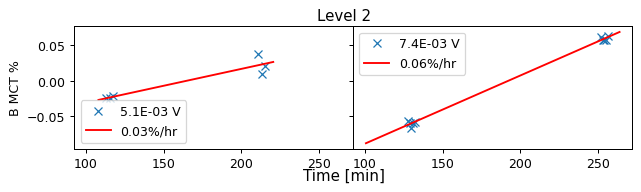

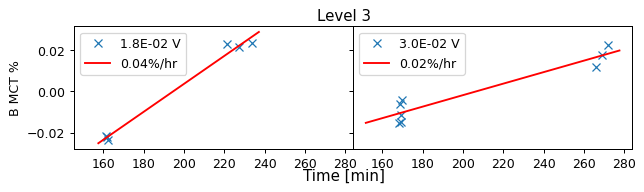

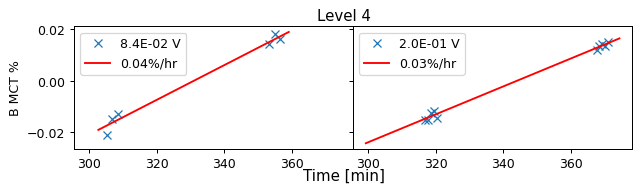

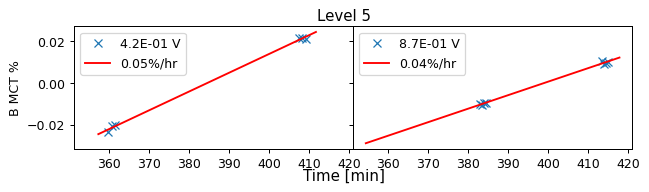

In [13]:
# plot time vs. light level for single-LED states

ipd = 1
pickexp = -3

mlight = statenum!=0
ilmidtime = midtime[mlight] # in minutes

b1stt = np.zeros(levels-1)
b1slp = np.zeros(levels-1)
b2stt = np.zeros(levels-1)
b2slp = np.zeros(levels-1)

for ilev in range(1, levels):
    fig, ax = plt.subplots(1, 2, figsize=(2*4., 2.), dpi=90,
                           sharex=True, sharey=True)
    fig.subplots_adjust(hspace=0, wspace=0., bottom=0.2)
    mb1il = (ilstates[:, 0]==ilev) & (ilstates[:, 1]==0)
    _, percdist = percplot(ax[0], ilmidtime[mb1il]/60., PDsigs[ipd, mb1il]*(1.-fvfaf[mb1il,0]),
                           yl=pdlabels[ipd]+' %', legformat='.1E', legunit='V', plsym='x')
    pp = np.polyfit(ilmidtime[mb1il], percdist[0], 1)
    xx = np.linspace(*ax[0].get_xlim(), 100)
    ax[0].plot(xx, np.polyval(pp, xx*60.), 'r', label=f'{3600.*pp[0]:.2f}%/hr')
    ax[0].legend()
    b1stt[ilev-1] = ilmidtime[mb1il][pickexp]
    b1slp[ilev-1] = pp[0]/100.
    mb2il = (ilstates[:, 0]==0) & (ilstates[:, 1]==ilev)
    _, percdist = percplot(ax[1], ilmidtime[mb2il]/60., PDsigs[ipd, mb2il]*(1.-fvfaf[mb2il,1]),
                    legformat='.1E', legunit='V', plsym='x')
    pp = np.polyfit(ilmidtime[mb2il], percdist[0], 1)
    xx = np.linspace(*ax[1].get_xlim(), 100)
    ax[1].plot(xx, np.polyval(pp, xx*60.), 'r', label=f'{3600.*pp[0]:.2f}%/hr')
    ax[1].legend()
    b2stt[ilev-1] = ilmidtime[mb2il][pickexp]
    b2slp[ilev-1] = pp[0]/100.

    if ilev==1:
        ax[0].set_title('Bank 1')
        ax[1].set_title('Bank 2')

    fig.suptitle(f'Level {ilev}')
    fig.supxlabel('Time [min]')

    

In [14]:
tfaf = np.zeros((len(ilstates), 2))

for ilev in range(1, levels):
    mm = ilstates[:, 0]==ilev
    toff = ilmidtime[mm] - b1stt[ilev-1]
    tfaf[mm, 0] = toff*b1slp[ilev-1]
    mm = ilstates[:, 1]==ilev
    toff = ilmidtime[mm] - b2stt[ilev-1]
    tfaf[mm, 1] = toff*b2slp[ilev-1]
    

In [15]:
# faf = (1. + fvfaf)*(1. + tfaf) - 1.
# faf = tfaf
# faf = fvfaf

nlight = len(ilstates)
s_scale = 2.e-3
ignore_periods = []
# ignore_periods = np.arange(32)
# ignore_periods = np.arange(32, 64)

ndegs = np.array([3, 1])
custom = 0
flux0 = False

PDerrs = 10.*orig_PDerrs
# PDerrs = PDadjerrs
npd = len(PDsigs)

if 'Asing' not in locals():
    Asing = np.unique(ilstates[:, 0])
    Bsing = np.unique(ilstates[:, 1])
    Alevels = len(Asing)
    Blevels = len(Bsing)

provide_fluxadj = False
if provide_fluxadj:
    fluxadjfacs = (faf[:, 0], faf[:, 1])
else:
    fluxadjfacs = None


In [16]:
faf_fn = 'tfaf.npz'
# faf_fn = 'bothfaf.npz'
# np.savez(savdir+faf_fn, fluxadjfacs)

savdict = np.load(directory+'savs/'+faf_fn)
fluxadjfacs = savdict['arr_0']


NameError: name 'directory' is not defined


*** PD 1 Real Data with Bootstrap Errors ***

** Fit function: F = S( 1 - α[ln(S/S₀)]^1 - β[ln(S/S₀)]^2 - γ[ln(S/S₀)]^3 )
                 where S₀ = 2.0e-03 V

                                              CFA Results

  Fit Quantity               Best Fit Value     Err(est)     % Error(est)
      α                       -6.944e-04       4.485e-04
      β                        1.485e-03       9.030e-05
      γ                       -1.708e-04       5.938e-06
 LED 1 Flux  1                 1.290e-03       1.035e-06      8.02e-02
 LED 1 Flux  2                 5.716e-03       3.195e-06      5.59e-02
 LED 1 Flux  3                 3.408e-02       2.525e-05      7.41e-02
 LED 1 Flux  4                 1.128e-01       8.535e-05      7.56e-02
 LED 1 Flux  5                 5.165e-01       3.874e-04      7.50e-02
 LED 2 Flux  1                 2.762e-03       1.467e-06      5.31e-02
 LED 2 Flux  2                 1.144e-02       7.130e-06      6.23e-02
 LED 2 Flux  3                 5.669e

/Users/tperera/python/tpCFAsuite.py:89: RuntimeWarning: divide by zero encountered in matmul
  cova = np.linalg.inv(Bmat.T @ gmat @ Bmat)
/Users/tperera/python/tpCFAsuite.py:89: RuntimeWarning: overflow encountered in matmul
  cova = np.linalg.inv(Bmat.T @ gmat @ Bmat)
/Users/tperera/python/tpCFAsuite.py:89: RuntimeWarning: invalid value encountered in matmul
  cova = np.linalg.inv(Bmat.T @ gmat @ Bmat)
/Users/tperera/python/tpCFAsuite.py:96: RuntimeWarning: divide by zero encountered in matmul
  rhs = sgmat @ yvec
/Users/tperera/python/tpCFAsuite.py:96: RuntimeWarning: overflow encountered in matmul
  rhs = sgmat @ yvec
/Users/tperera/python/tpCFAsuite.py:96: RuntimeWarning: invalid value encountered in matmul
  rhs = sgmat @ yvec
/Users/tperera/python/tpCFAsuite.py:97: RuntimeWarning: divide by zero encountered in matmul
  lmat = sgmat @ Bmat
/Users/tperera/python/tpCFAsuite.py:97: RuntimeWarning: overflow encountered in matmul
  lmat = sgmat @ Bmat
/Users/tperera/python/tpCFAsuite.p

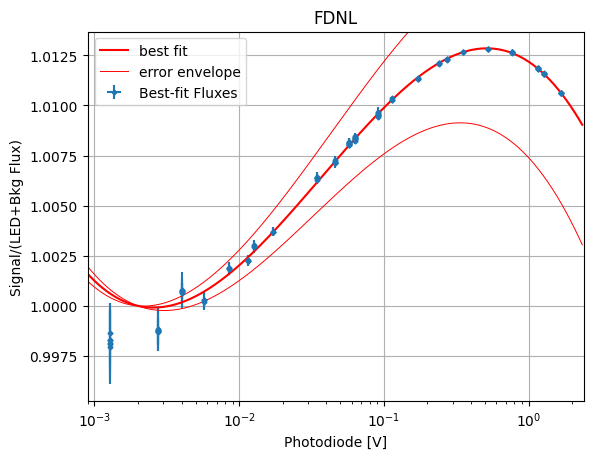


*** PD 2 Real Data with Bootstrap Errors ***

** Fit function: F = S( 1 - α[ln(S/S₀)]^1 )
                 where S₀ = 2.0e-03 V

                                              CFA Results

  Fit Quantity               Best Fit Value     Err(est)     % Error(est)
      α                        4.840e-04       1.795e-05
 LED 1 Flux  1                 1.258e-03       2.538e-07      2.02e-02
 LED 1 Flux  2                 5.551e-03       6.023e-07      1.08e-02
 LED 1 Flux  3                 3.307e-02       2.981e-06      9.01e-03
 LED 1 Flux  4                 1.095e-01       1.088e-05      9.93e-03
 LED 1 Flux  5                 5.009e-01       5.355e-05      1.07e-02
 LED 2 Flux  1                 2.688e-03       2.987e-07      1.11e-02
 LED 2 Flux  2                 1.111e-02       7.540e-07      6.79e-03
 LED 2 Flux  3                 5.504e-02       4.277e-06      7.77e-03
 LED 2 Flux  4                 2.301e-01       2.195e-05      9.54e-03
 LED 2 Flux  5                 1.112e+00 

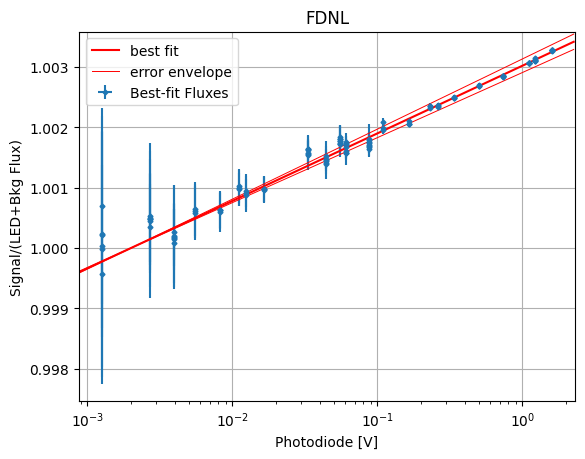

In [ ]:
# import tpCFAsuite as tc

exec(tpu.tpr(expanduser('~/python/tpCFAsuite')))

fl1arr = []
fl1_errarr = []
fl2arr = []
fl2_errarr = []

for ipd in range(npd):

    ndeg = ndegs[ipd]

    fl1, fl1_err, fl2, fl2_err, fc, fc_err, rX2, whb, yyvec, BBmat, ggmat, ffitvals, ffitmask = \
        CFAana((PDsigs[ipd], PDerrs[ipd]), ilstates,
               weight_calc=True, ndeg=ndeg, s_scale=s_scale,
               flux0=flux0, custom=custom, fullout=True, fluxadjfacs=fluxadjfacs)

    nndof = GetNDOF(nlight, whb, fl1, fl2, fc)
    
    bfl1, bfl1_err, bfl2, bfl2_err, bfc, bfc_err, brX2, brX2_err, optimism = \
        bootstrap_cfa(PDsigs[ipd], PDerrs[ipd], niter=100)

    print()
    print(f'*** PD {ipd+1} Real Data with Bootstrap Errors ***')

    print_cfa_results(fl1, bfl1_err, fl2, bfl2_err, fc, bfc_err, rX2, s_scale=s_scale, ndeg=ndeg,
                      flux0=flux0, custom=custom)

    gma = np.ones(len(ilstates)).astype('bool')
    if len(whb)>0:
        gma[whb] = False

    if fluxadjfacs is None:
        fafs = None
    else:
        fafs = (fluxadjfacs[0][gma], fluxadjfacs[1][gma])

    plot_cfa_results(ilstates[gma], PDsigs[ipd, gma], PDerrs[ipd, gma], fl1, bfl1_err, fl2, bfl2_err, fc, bfc_err,
                     s_scale=s_scale, ndeg=ndeg, flux0=flux0, custom=custom, show_fluxerr=False,
                     fluxadjfacs=fafs)

    fl1arr.append(fl1)
    fl1_errarr.append(bfl1_err)
    fl2arr.append(fl2)
    fl2_errarr.append(bfl2_err)

fl1arr = np.array(fl1arr)
fl1_errarr = np.array(fl1_errarr)
fl2arr = np.array(fl2arr)
fl2_errarr = np.array(fl2_errarr)
